In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from generators import CifarImagePatches
from continuous_networks import RateLateralInhibitoryLayer

screen_size = 12
gen_params = CifarImagePatches.default_params()
gen_params['patch_size'] = screen_size
gen_params["whitening"] = "zca"
np.random.seed(42)
gen = CifarImagePatches(gen_params)

# 2. Setup Network
hparams = RateLateralInhibitoryLayer.default_hparams((screen_size*2, screen_size, 1))
hparams["num_units_y"] = 300  # Number neurons in the layer
hparams["w_lr"] = 0.001  # Feedforward learning rate
hparams["m_lr"] = 0.002  # Lateral inhibitory learning rate
hparams["w_update"] = "hebbian"
hparams['voltage_threshold'] = '0.5'  # Threshold for neuron activation
#hparams["m_bandwidth"] = None  # Enforce local inhibition (bandwidth of 3) ##TODO: Implement bandwidths
#hparams["m_init"] = "WWT" ##TODO: Try different initializations

net = RateLateralInhibitoryLayer(hparams)

Using downloaded and verified file: /var/folders/5_/xl72hmzs3334b968v34w6w600000gn/T/cifar10_tv/cifar-10-python.tar.gz
Extracting /var/folders/5_/xl72hmzs3334b968v34w6w600000gn/T/cifar10_tv/cifar-10-python.tar.gz to /var/folders/5_/xl72hmzs3334b968v34w6w600000gn/T/cifar10_tv


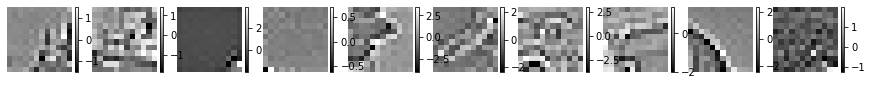

In [4]:
# plot some images from generator
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
np.random.seed(42)
gen.set_random_position()
img = gen.get_current_frame()
for i in range(10):
    gen.set_random_position()
    img = gen.get_current_frame()
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].axis("off")
    plt.colorbar(axes[i].imshow(img.squeeze(), cmap="gray"), ax=axes[i], fraction=0.046, pad=0.04)

In [5]:
net.reset_network()
np.random.seed(42)

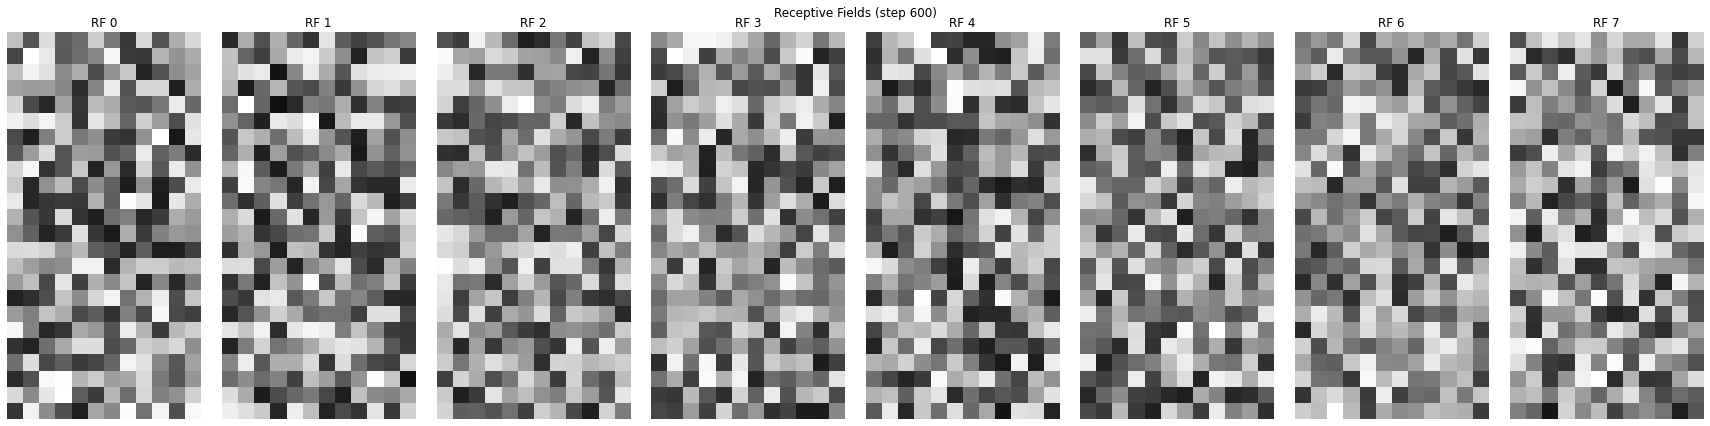

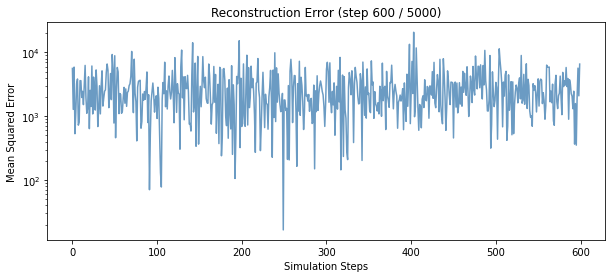

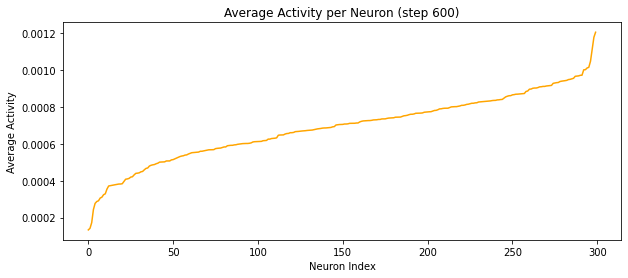

In [ ]:
from IPython.display import clear_output

num_steps = 5000
num_static_stimuli = 100
plot_every = 100
errors = []


fig, ax = plt.subplots(figsize=(10, 4))

for step in range(num_steps):
    gen.set_random_position()
    frame = gen.get_current_frame().copy()
    # frame[frame < 0] = 0  # Ensure non-negativity for visualization
    # onoff_frame = 2 * np.vstack([frame * (frame > 0), -frame * (frame < 0)])
    onoff_frame = 1 * np.vstack([frame * (frame > 0), -frame * (frame < 0)])
    # run the network for an number of iterations with static stimuli
    for _ in range(num_static_stimuli):
        net.gradient_step(onoff_frame)
        net.update_parameters()

    recon = net.projection()
    mse = np.mean((onoff_frame.flatten() - recon.flatten()) ** 2)
    errors.append(mse)

    if (step + 1) % plot_every == 0:
        clear_output(wait=True)
        ax.cla()
        ax.semilogy(errors, alpha=0.8, color='steelblue')
        ax.set_title(f"Reconstruction Error (step {step + 1} / {num_steps})")
        ax.set_xlabel("Simulation Steps")
        ax.set_ylabel("Mean Squared Error")
        # Plot a few receptive fields during training
        num_show = min(8, net.w.shape[0])
        fig_rf, rf_axes = plt.subplots(1, num_show, figsize=(3 * num_show, 6))
        if num_show == 1:
            rf_axes = [rf_axes]

        for j in range(num_show):
            rf_img = net.w[j].reshape(screen_size*2, screen_size)
            vmax = np.max(np.abs(rf_img))
            rf_axes[j].imshow(rf_img, cmap='gray', vmin=0, vmax=vmax)
            rf_axes[j].set_title(f"RF {j}")
            rf_axes[j].axis("off")

        fig_rf.suptitle(f"Receptive Fields (step {step + 1})")
        plt.tight_layout()
        display(fig_rf)
        plt.close(fig_rf)
        display(fig)
        plt.close(fig)
        fig_avg, ax_avg = plt.subplots(figsize=(10, 4))
        ax_avg.plot(range(net.num_units_y), sorted(net.track_y/net.iteration), color='orange')
        ax_avg.set_title(f"Average Activity per Neuron (step {step + 1})")
        ax_avg.set_xlabel("Neuron Index")
        ax_avg.set_ylabel("Average Activity")
        display(fig_avg)
        plt.close(fig_avg)

plt.close(fig)

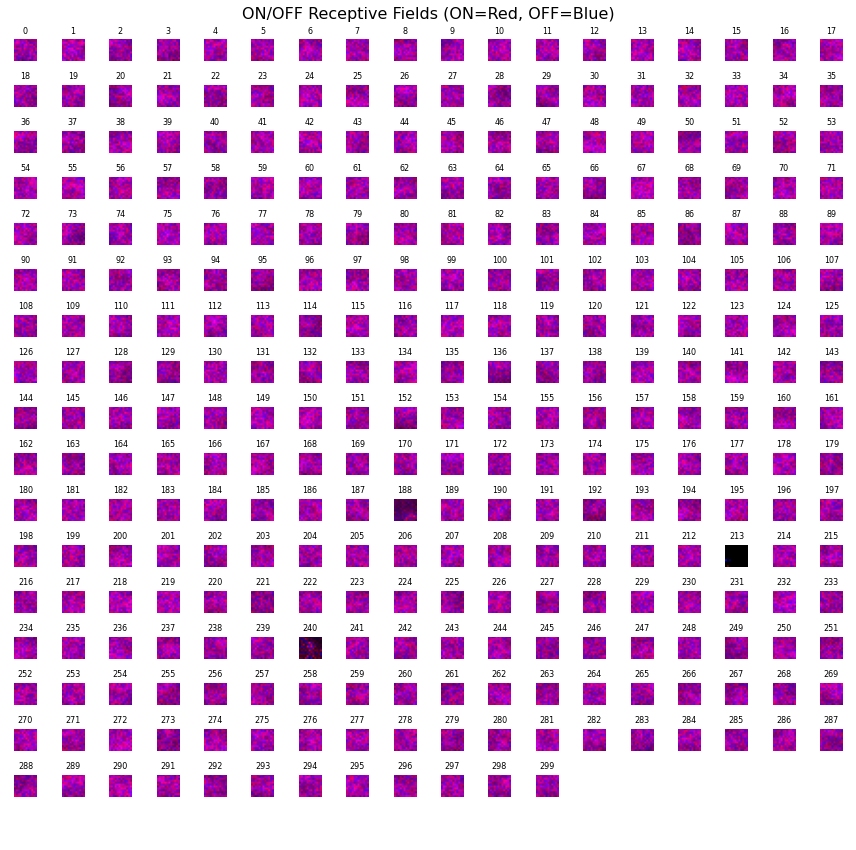

In [7]:
# Plot RFs by combining ON (top half) and OFF (bottom half) into one color image per neuron
W = net.w
num_units = W.shape[0]
grid_size = int(np.ceil(np.sqrt(num_units)))

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
fig.suptitle("ON/OFF Receptive Fields (ON=Red, OFF=Blue)", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    if i < num_units:
        rf = W[i].reshape(screen_size * 2, screen_size)

        # First square: ON, second square: OFF
        # on_map = np.maximum(rf[:screen_size, :], 0)
        # off_map = np.maximum(rf[screen_size:, :], 0)
        on_map = rf[:screen_size, :]
        off_map = rf[screen_size:, :]

        # Normalize jointly so red/blue intensity is comparable
        vmax = max(on_map.max(), off_map.max(), 1e-12)

        rgb = np.zeros((screen_size, screen_size, 3))
        rgb[..., 0] = on_map / vmax   # Red channel = ON
        rgb[..., 2] = off_map / vmax  # Blue channel = OFF

        ax.imshow(np.clip(rgb, 0, 1))
        ax.set_title(f"{i}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

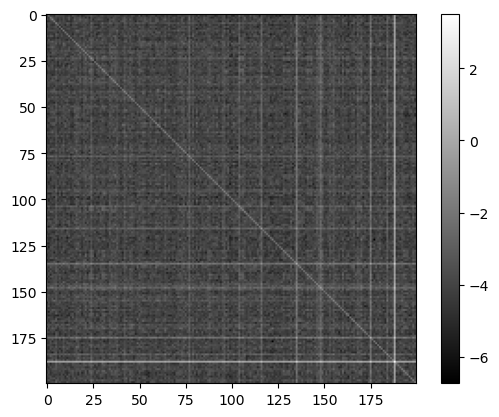

In [6]:
plt.imshow(np.log(net.m), cmap="gray")
# plt.imshow((net.m), cmap="gray")` is a commented-out line of code. This means that it is not being executed when the code is run. It is used for documentation purposes or to temporarily disable a line of code without deleting it. In this case, it seems like the line was originally used to display the image `net.m` using a grayscale colormap, but it has been commented out and is not affecting the output of the code.
# plt.imshow((net.m), cmap="gray")
plt.colorbar()

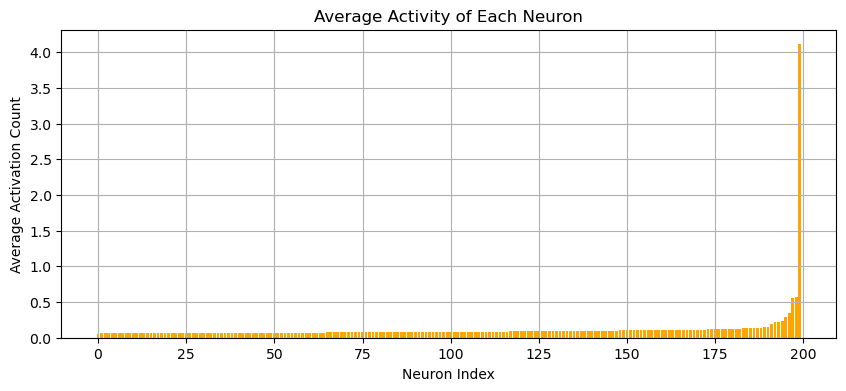

In [7]:
#show the average activity of each neuron ordered by activity
plt.figure(figsize=(10, 4))
plt.bar(range(num_units), sorted(net.track_y/net.iteration), color='orange')
plt.title("Average Activity of Each Neuron")
plt.xlabel("Neuron Index")
plt.ylabel("Average Activation Count")
plt.grid(True)
plt.show()
